# Make figures for changepoint detection paper

In [1]:
import xarray as xr
import numpy as np
import os
from glob import glob
from helpful_utilities import xutils
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from cartopy.mpl.gridliner import LONGITUDE_FORMATTER, LATITUDE_FORMATTER
import matplotlib.ticker as mticker
import string
import matplotlib.gridspec as gridspec
from cartopy.util import add_cyclic_point

import matplotlib.pyplot as plt
from matplotlib.colors import BoundaryNorm
%matplotlib inline

In [2]:
from helpful_utilities.plotting import easy_map
from helpful_utilities.ncutils import lon_to_180, lon_to_360

In [3]:
procdir = '/home/data/projects/homogenization/proc'
figdir = '/home/kmckinnon/homogenization/figs'
fontsize = 12
labelsize = 10

letters = list(string.ascii_lowercase)


In [4]:
f_lsmask_1x1 = '/home/data/ERA5/fx/era5_lsmask_1x1.nc'
da_lsmask_1x1 = xr.open_dataarray(f_lsmask_1x1)
landcut = 0.5

In [5]:
# get aridity index based on TerraClim climatologies
tc_ppt = lon_to_360(xr.open_dataarray('/home/data/Terraclim/PPT_Terraclim_1980_2020_native.nc').sortby('lat'))
tc_pet = lon_to_360(xr.open_dataarray('/home/data/Terraclim/PET_Terraclim_1980_2020_native.nc').sortby('lat'))

arid_idx_1x1 = (tc_ppt / tc_pet).interp({'lat': da_lsmask_1x1.lat, 'lon': da_lsmask_1x1.lon})

/home/kmckinnon/.conda/envs/homogenization/lib/python3.12/site-packages/scipy/interpolate/_interpolate.py:501: RuntimeWarning: invalid value encountered in subtract
  slope = (y_hi - y_lo) / (x_hi - x_lo)[:, None]
/home/kmckinnon/.conda/envs/homogenization/lib/python3.12/site-packages/scipy/interpolate/_interpolate.py:504: RuntimeWarning: invalid value encountered in add
  y_new = slope*(x_new - x_lo)[:, None] + y_lo


In [6]:
is_arid_semi = ((arid_idx_1x1 > 0.05) & (arid_idx_1x1 < 0.5)).where(da_lsmask_1x1.squeeze() > landcut)


## Synthetic tests: load data

In [7]:
synth_cp_std = 0.5
seed = 27

In [8]:
# Contains the trend, AR(1), and seasonally-varying variance for each gridbox
ds_residual_metrics = xr.open_dataset('%s/residual_metrics.nc' % procdir)

In [9]:
# # Check that the synthetic data is correct
# da_synth_data = xr.open_dataarray('%s/synth_residuals_seed-%i.nc' % (procdir, seed))

# da_delta = da_synth_data.groupby('time.month') - da_synth_data.groupby('time.month').mean()

# # For each gridbox, calculate trend, variance, AR(1)
# trend, _ = xutils.xr_linregress_pval(da_delta, time_dim='time')

# # remove trend to get variance
# da_detrended = xutils.detrend_xarray(da_delta, dim='time')

# std_by_month = da_detrended.groupby('time.month').std()

# # get autocorrelation -- shift by 1
# ar1 = xr.corr(da_detrended.shift(time=1), da_detrended, dim='time')

In [10]:
# landmask
mask = ~np.isnan(ds_residual_metrics['trend per year'])

# Truth
# actual changepoint magnitude
da_cp_synth = xr.open_dataarray('%s/synth_cps_cpmag_sigma-%0.1f_seed-%i.nc' % (procdir, synth_cp_std, seed))
# actual changepoint time index -- cannot be in first and last 5 years (60 time points)
da_cp_time_synth = xr.open_dataarray('%s/synth_cps_time_sigma-%0.1f_seed-%i.nc' % (procdir, 
                                                                                   synth_cp_std, seed))

In [11]:
# Output from using PELT
# detected changepoint magnitude
da_delta_at_cp_synth = xr.open_dataarray('%s/da_delta_at_cp_synth_sigma-%0.1f_seed-%i.nc' % (procdir, 
                                                                                             synth_cp_std,
                                                                                             seed))
# other info e.g. time of changepoint
ds_cp_info_synth = xr.open_dataset('%s/ds_cp_info_synth_sigma-%0.1f_seed-%i.nc' % (procdir, 
                                                                                   synth_cp_std, seed))

In [12]:
print('There are %i gridboxes analyzed' % (np.sum(mask==1)))

There are 15080 gridboxes analyzed


## Plot: hit / miss / false alarm histogram as a function of CP magnitude + role of different characteristics

In [13]:
# Time of actual CP
idx_actual = da_cp_time_synth
# Time CP was detected - first changepoint only
idx_detected = ds_cp_info_synth['cp_index'].sel(cp=0)

In [14]:
is_land_vec = mask.values.flatten()

In [15]:
# Hit is defined as a changepoint found within a year on either side
hit = (idx_detected >= (idx_actual - 12)) & (idx_detected <= (idx_actual + 12))
# Miss: no changepoint found
miss = (ds_cp_info_synth['cp_count']==1)
# False alarm: changepoint found, but not at the right time
false_alarm = (ds_cp_info_synth['cp_count'] > 1) & ~hit


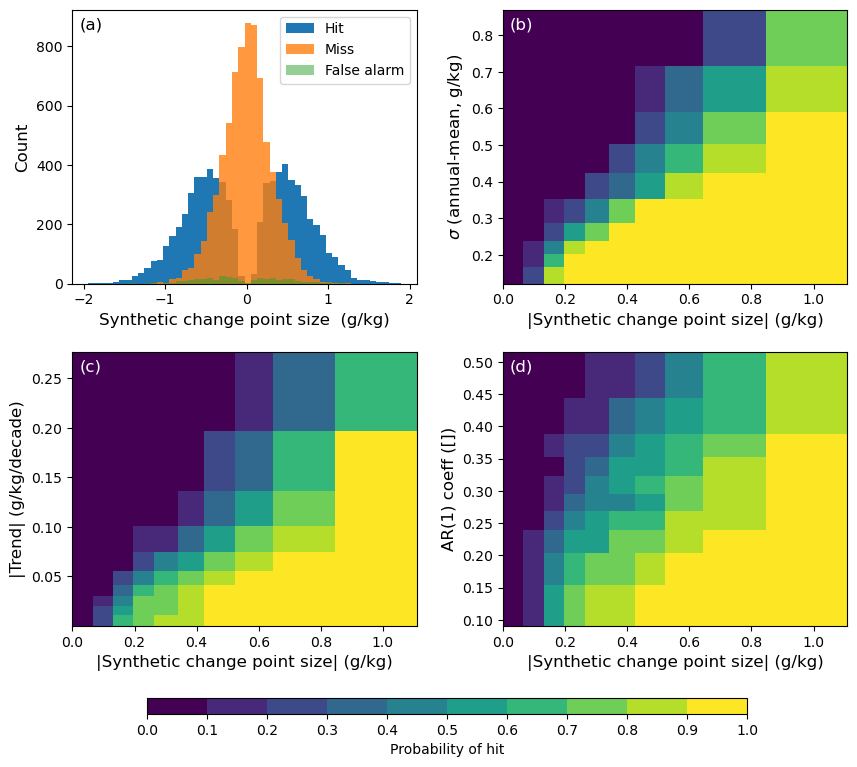

In [16]:
fig, axes = plt.subplots(figsize=(10, 8), ncols=2, nrows=2, gridspec_kw={'wspace': 0.25, 'hspace': 0.25})

# For probability plots
bounds = np.arange(0, 1.01, 0.1)
cmap = plt.get_cmap('viridis', len(bounds)-1)
norm = BoundaryNorm(bounds, cmap.N)

bin_qsize = 10
bins_q = np.arange(0, 100 + bin_qsize, bin_qsize) / 100
bin_middle = (bins_q[1:] + bins_q[:-1]) / 2
nbins = len(bins_q) - 1

var1 = np.abs(da_cp_synth.where(mask))
name1 = '|Synthetic change point size| (g/kg)'

for ct, ax in enumerate(axes.flatten()):
    if ct == 0: # histograms
        nhit, bins, _ = ax.hist(da_cp_synth.where(hit).values.flatten(), bins=50, label='Hit')
        nmiss, _, _ = ax.hist(da_cp_synth.where(miss).values.flatten(), bins=bins, label='Miss', alpha=0.8)
        nFA, _, _ = ax.hist(da_cp_synth.where(false_alarm).values.flatten(), bins=bins, label='False alarm', 
                             alpha=0.5)
        ax.legend()
        ax.set_xlabel('Synthetic change point size  (g/kg)', fontsize=fontsize)
        ax.set_ylabel('Count', fontsize=12)
        ax.text(0.02, 0.93, '(a)', fontsize=fontsize, transform=ax.transAxes)
        
    else:

        if ct == 1:
            var2 = (np.sqrt((ds_residual_metrics['sigma'] ** 2).mean('month')))
            name2 = r'$\sigma$ (annual-mean, g/kg)'
        elif ct == 2:
            var2 = 10 * np.abs(ds_residual_metrics['trend per year'])
            name2 = '|Trend| (g/kg/decade)'
        else:
            var2 = ds_residual_metrics['AR1 coeff']
            name2 = 'AR(1) coeff ([])'


        p_hit = np.empty((nbins, nbins))
        for i in range(nbins):
            for j in range(nbins):
                idx1 = (var1 >= var1.quantile(bins_q[i])) & (var1 < var1.quantile(bins_q[i + 1]))
                idx2 = (var2 >= var2.quantile(bins_q[j])) & (var2 < var2.quantile(bins_q[j + 1]))

                in_bin = idx1 & idx2
                p_hit[j, i] = hit.where(in_bin).sum() / ((hit + miss + false_alarm).where(in_bin).sum())

        xlabel = var1.quantile(bin_middle)
        ylabel = var2.quantile(bin_middle)
        # fig, ax = plt.subplots(figsize=(8, 5))

        im = ax.pcolormesh(
            xlabel, ylabel, p_hit,
            cmap=cmap, norm=norm,
            shading='auto'
        )

        ax.set_xlabel(name1, fontsize=fontsize)
        ax.set_ylabel(name2, fontsize=fontsize)
        
        ax.text(0.02, 0.93, '(%s)' % letters[ct], color='white', 
                fontsize=fontsize, transform=ax.transAxes)

# after creating your figure and subplots
fig = plt.gcf()

# [left, bottom, width, height] in figure coordinates (0–1)
cax = fig.add_axes([0.2, 0, 0.6, 0.02])

cbar = fig.colorbar(im, cax=cax, orientation='horizontal')
cbar.set_label('Probability of hit')
cbar.set_ticks(bounds)
cbar.set_ticklabels([f'{b:.1f}' for b in bounds])

# plt.savefig('%s/fig01.png' % figdir, dpi=200, bbox_inches='tight')

In [17]:
phit = nhit / (nhit + nmiss + nFA)
bin_mid = 1/2 * (bins[1:] + bins[:-1])

print('50 percent chance of hit: %0.2f' % bin_mid[np.argmin(np.abs(phit - 0.5))])
print('75 percent chance of hit: %0.2f' % bin_mid[np.argmin(np.abs(phit - 0.75))])


50 percent chance of hit: 0.32
75 percent chance of hit: -0.60


## ERA5 and HadISDH changepoint results map and years

In [18]:
data_names = ['ERA5', 'HadISDH']
years = 1980, 2024

In [19]:
f = '%s/ds_cp_info_%s_%04i-%04i.nc' % (procdir, 'HadISDH', years[0], years[1])
ds_cp = xr.open_dataset(f)
# In mask, 1 = missing
had_mask = ds_cp.sel(cp=0)['model_code'] == -1 

had_lsmask = xr.open_dataarray('/home/data/ERA5/fx/era5_lsmask_5x5_conservative.nc')
had_lsmask = had_lsmask.squeeze()

In [20]:
# 1 is missing over land only for stippling
had_mask = had_mask & (had_lsmask > landcut).astype(bool).sel(lat=had_mask.lat)

min-max range: -1.62-1.45
min-max range: -2.84-1.36


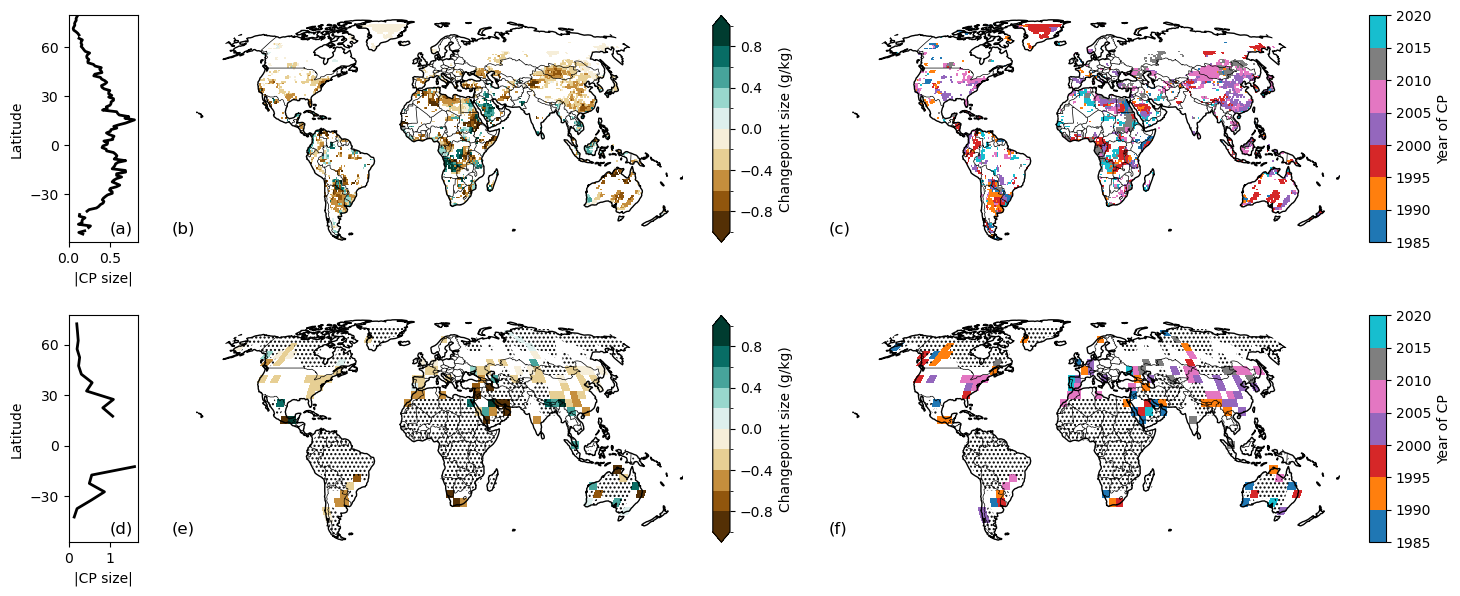

In [21]:
nrows = len(data_names) + 1
ncols = 3 + 2 + 1

proj = ccrs.Robinson(central_longitude=0)
cp_to_plot = 0  # plot first changepoint (0) or second (1)

fig = plt.figure(figsize=(17, 7))

gs = gridspec.GridSpec(
    nrows=nrows,
    ncols=ncols,
    width_ratios=[0.8, 6, 0.2, 0.4, 6, 0.2],
    height_ratios=[1, 0.05, 1],
    wspace=0.15,
    hspace=0.15
)

letter_ct = 0

for ct, data_name in enumerate(data_names):

    # Plot profile and map
    ax_prof = fig.add_subplot(gs[ct, 0])

    f = '%s/da_delta_at_cp_withAR_%s_%04i-%04i.nc' % (procdir, data_name, years[0], years[1])
    with xr.open_dataarray(f) as da_mag:
        smooth_prof = (np.abs(da_mag).sel(cp=cp_to_plot).mean('lon'))
        lat_min = da_mag['lat'].min().values
        lat_max = da_mag['lat'].max().values

    smooth_prof.plot(ax=ax_prof, y='lat', color='k', lw=2)
    ax_prof.set_xlabel('|CP size|')
    if ct == 0:
        ax_prof.set_xticks((0, 0.5))
    else:
        ax_prof.set_xticks((0, 1))

    ax_prof.set_yticks(np.arange(-60, 80, 30))
    ax_prof.set_ylabel('Latitude')
    ax_prof.set_title('')
    ax_prof.set_ylim(lat_min, lat_max)
    ax_prof.text(0.6, 0.04, '(%s)' % letters[letter_ct], fontsize=fontsize, transform=ax_prof.transAxes)
    letter_ct += 1

    for map_ct in range(2):
        ax_map = fig.add_subplot(gs[ct * 2, 1 + 3 * map_ct], projection=proj)
        ax_map.set_aspect('equal')

        if map_ct == 0:
            # Plot CP magnitude
            cmap = plt.cm.BrBG
            levels = np.arange(-1, 1.1, 0.2)
            label = 'Changepoint size (g/kg)'
            extend = 'both'
            norm = BoundaryNorm(levels, ncolors=256)

            f = '%s/da_delta_at_cp_withAR_%s_%04i-%04i.nc' % (procdir, data_name, years[0], years[1])
            with xr.open_dataarray(f) as da_mag:
                to_plot = da_mag.sel(cp=cp_to_plot)

            print('min-max range: %0.2f-%0.2f' % (to_plot.min(), to_plot.max()))

        else:
            # Plot CP year
            cmap = plt.cm.tab10
            ncolors = 10
            levels = np.arange(1985, 2021, 5)
            label = 'Year of CP'
            extend = 'neither'
            norm = BoundaryNorm(levels, ncolors=ncolors)

            cp_info_file = '%s/ds_cp_info_%s_%i-%i.nc' % (procdir, data_name, years[0], years[1])
            with xr.open_dataset(cp_info_file) as ds_cp_info:
                to_plot = ds_cp_info['cp_time'].sel(cp=cp_to_plot).dt.year
                has_cp = ds_cp_info['cp_count'] >= 2
                to_plot = to_plot.where(has_cp & (to_plot < years[-1]))

        lon = to_plot['lon'].values
        lat = to_plot['lat'].values
        dat = to_plot.values

        dat_cyc, lon_cyc = add_cyclic_point(dat, coord=lon)

        im = ax_map.pcolormesh(
            lon_cyc,
            lat,
            dat_cyc,
            cmap=cmap,
            norm=norm,
            transform=ccrs.PlateCarree(),
            shading='auto'
        )

        ax_map.add_feature(cfeature.COASTLINE, zorder=100.)
        ax_map.set_global()
        ax_map.axis('off')
        ax_map.set_extent([-180, 180, -57, 90], crs=ccrs.PlateCarree())
        ax_map.set_title('')

        # HadISDH hatch overlay, rendered in same cyclic/pcolormesh-aligned style
        if data_names[ct] == 'HadISDH':
           
            had_lon = had_mask['lon'].values
            had_lat = had_mask['lat'].values
            had_dat = had_mask.values
            had_cyc, had_lon_cyc = add_cyclic_point(had_dat, coord=had_lon)

            ax_map.contourf(
                had_lon_cyc,
                had_lat,
                had_cyc,
                levels=[-0.5, 0.5, 1.5],
                hatches=[None, '....'],
                colors='none',
                transform=ccrs.PlateCarree(),
                zorder=101
            )

        ax_map.text(0.01, 0.04, '(%s)' % letters[letter_ct], fontsize=fontsize, transform=ax_map.transAxes)
        ax_map.add_feature(cfeature.BORDERS, linewidth=0.5)
        letter_ct += 1

        # Colorbar (layout preserved)
        cax = fig.add_subplot(gs[ct, 2 + 3 * map_ct])
        fig.colorbar(im, cax=cax, extend=extend)
        cax.set_ylabel(label)

        fig.canvas.draw()  # important: positions aren't final until draw

        # match cax height to map height
        pos_map = ax_map.get_position()
        pos_cax = cax.get_position()
        cax.set_position([pos_cax.x0, pos_map.y0, pos_cax.width, pos_map.height])

        # match profile height too (optional)
        pos_prof = ax_prof.get_position()
        ax_prof.set_position([pos_prof.x0, pos_map.y0, pos_prof.width, pos_map.height])
        
if cp_to_plot == 0:
    plt.savefig('%s/fig02.png' % figdir, dpi=200, bbox_inches='tight')
else:
    plt.savefig('%s/figS03.png' % figdir, dpi=200, bbox_inches='tight')

In [22]:
# print out stats for ERA5 -- land are with changepoint
f = '%s/ds_cp_info_%s_%04i-%04i.nc' % (procdir, 'ERA5', years[0], years[1])
with xr.open_dataset(f) as ds_cp:
    has_cp = ds_cp['cp_count']
area_with_cp = xutils.area_weighted_average((has_cp > 1).where(has_cp > 0))
f = '%s/da_delta_at_cp_withAR_%s_%04i-%04i.nc' % (procdir, 'ERA5', years[0], years[1])
with xr.open_dataarray(f) as da_mag:
    median_cp = np.abs(da_mag).median()

print('ERA5 stats')
print('Fraction of land area with CP: %0.2f' % area_with_cp)
print('Median CP magnitude: %0.2f' % median_cp)


ERA5 stats
Fraction of land area with CP: 0.31
Median CP magnitude: 0.40


# S1: maps of characteristics

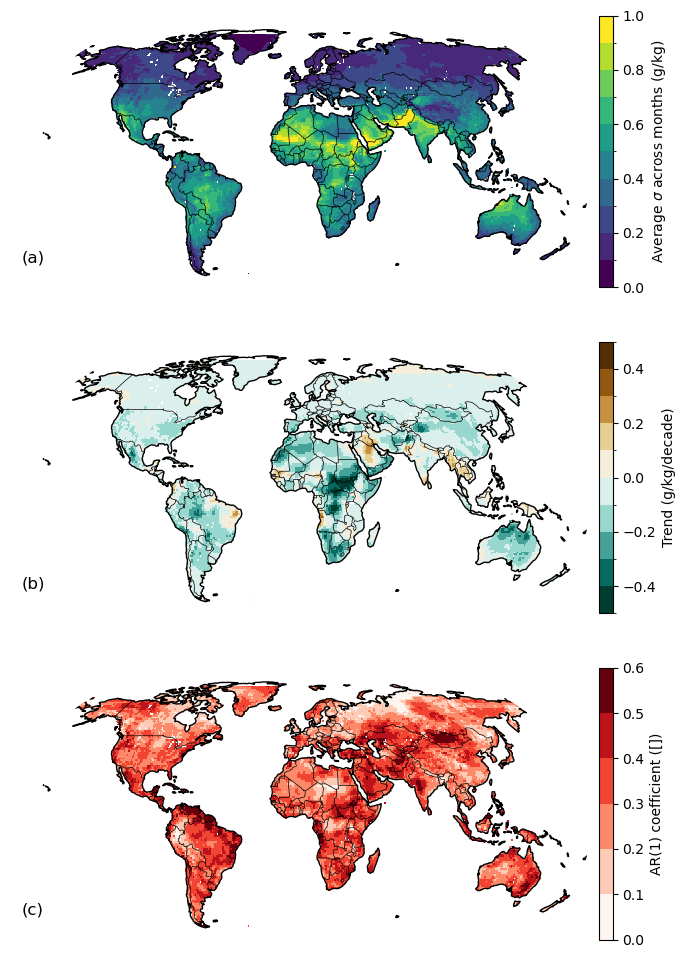

In [23]:
# Updated to match the other plots:
# - Robinson(central_longitude=0)
# - pcolormesh (not xarray .plot)
# - add_cyclic_point to avoid seam
# - axis off + set_extent like colleague style
# - manual colorbars (one per panel), consistent placement

# Make plot
nrows = 3
ncols = 1
proj = ccrs.Robinson(central_longitude=0)

fig, axes = plt.subplots(
    nrows=nrows,
    ncols=ncols,
    figsize=(8 * ncols, 4 * nrows),
    subplot_kw={'projection': proj}
)

for ct, ax in enumerate(np.atleast_1d(axes).flatten()):

    if ct == 0:
        to_plot = ds_residual_metrics['sigma'].mean('month')
        cmap = plt.cm.viridis
        label = r'Average $\sigma$ across months (g/kg)'
        levels = np.arange(0, 1.1, 0.1)

    elif ct == 1:
        to_plot = 10 * ds_residual_metrics['trend per year']
        cmap = plt.cm.BrBG_r
        label = 'Trend (g/kg/decade)'
        levels = np.arange(-0.5, 0.6, 0.1)

    else:
        to_plot = ds_residual_metrics['AR1 coeff']
        cmap = plt.cm.Reds
        label = 'AR(1) coefficient ([])'
        levels = np.arange(0, 0.7, 0.1)

    norm = BoundaryNorm(levels, ncolors=256)

    # pcolormesh expects arrays; add cyclic point to avoid a seam at 180°
    lon = to_plot['lon'].values
    lat = to_plot['lat'].values
    dat = to_plot.values
    dat_cyc, lon_cyc = add_cyclic_point(dat, coord=lon)

    im = ax.pcolormesh(
        lon_cyc,
        lat,
        dat_cyc,
        cmap=cmap,
        norm=norm,
        transform=ccrs.PlateCarree(),
        shading='auto'
    )

    ax.set_aspect('equal')
    ax.add_feature(cfeature.COASTLINE, zorder=100.)
    ax.set_global()
    ax.axis('off')
    ax.set_extent([-180, 180, -57, 90], crs=ccrs.PlateCarree())
    ax.set_title('')
    ax.add_feature(cfeature.BORDERS, linewidth=0.5)

    ax.text(0.02, 0.06, '(%s)' % letters[ct], fontsize=fontsize, transform=ax.transAxes)

    # Colorbar per panel (manual, like your other figure)
    cbar = fig.colorbar(im, ax=ax, orientation='vertical', pad=0.02, fraction=0.05)
    cbar.set_label(label)

plt.savefig('%s/figS01.png' % figdir, dpi=200, bbox_inches='tight')

In [24]:
# # Make plot
# nrows = 3
# ncols = 1
# fig, axes = plt.subplots(nrows=nrows, ncols=ncols, figsize=(8 * ncols, 3 * nrows),
#                          subplot_kw={'projection': ccrs.PlateCarree()})

# levels = np.arange(0, 1.1, 0.1)
# cmap = 'Reds'
# norm = BoundaryNorm(levels, ncolors=256)

# for ct, ax in enumerate(axes.flatten()):
    
#     if ct == 0:
#         to_plot = ds_residual_metrics['sigma'].mean('month')
#         cmap = plt.cm.viridis
#         label = r'Average $\sigma$ across months (g/kg)'
#         levels = np.arange(0, 1.1, 0.1)
    
#     elif ct == 1:
#         to_plot = 10 * ds_residual_metrics['trend per year']
#         cmap = plt.cm.BrBG_r
#         label = 'Trend (g/kg/decade)'
#         levels = np.arange(-0.5, 0.6, 0.1)
        
#     else:
#         to_plot = ds_residual_metrics['AR1 coeff']
#         cmap = plt.cm.Reds
#         label = 'AR(1) coefficient ([])'
#         levels = np.arange(0, 0.7, 0.1)
        
#     norm = BoundaryNorm(levels, ncolors=256)
#     im = (to_plot.rename(label)).plot(ax=ax,
#                       cmap=cmap,
#                       norm=norm,
#                       levels=levels,
#                       add_colorbar=True)
#     ax.coastlines()
#     ax.add_feature(cfeature.BORDERS, linewidth=0.5)
#     ax.add_feature(cfeature.OCEAN, facecolor='lightgray', zorder=1)
    
#     ax.text(0.02, 0.06, '(%s)' % letters[ct], fontsize=fontsize, transform=ax.transAxes)
    
# plt.savefig('%s/figS01.png' % figdir, dpi=200, bbox_inches='tight')


# S2 Validating changepoint magnitude for hits

bias: 0.04 g/kg
standard error: 0.11 g/kg
positive CPs
bias: 0.02 g/kg
standard error: 0.10 g/kg
negative CPs
bias: 0.05 g/kg
standard error: 0.12 g/kg


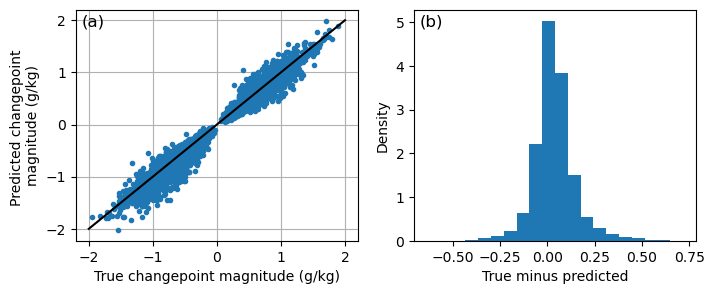

In [25]:
true_mag = da_cp_synth.where(hit).values.flatten()
predicted_mag = da_delta_at_cp_synth.isel(cp=0).values.flatten()

fig, axes = plt.subplots(figsize=(8, 3), ncols=2)
for ct, ax in enumerate(axes):
    if ct == 0:
        ax.plot(true_mag, predicted_mag ,'.')
        ax.plot([-2, 2], [-2,2 ], color='k')
        ax.grid()
        ax.set_xlabel('True changepoint magnitude (g/kg)')
        ax.set_ylabel('Predicted changepoint \nmagnitude (g/kg)')
    else:
        delta = true_mag - predicted_mag
        ax.hist(delta, bins=20, density=True)
        ax.set_xlabel('True minus predicted')
        ax.set_ylabel('Density')
    ax.text(0.02, 0.93, '(%s)' % letters[ct], fontsize=fontsize, transform=ax.transAxes)

plt.savefig('%s/figS02.png' % figdir, dpi=200, bbox_inches='tight')

print('bias: %0.2f g/kg' % np.nanmean(delta))
print('standard error: %0.2f g/kg' % np.nanstd(delta))

for ct in range(2):
    
    if ct == 0:
        idx = true_mag > 0
        print('positive CPs')
    else:
        idx = true_mag < 0
        print('negative CPs')
   
    print('bias: %0.2f g/kg' % np.nanmean(delta[idx]))
    print('standard error: %0.2f g/kg' % np.nanstd(delta[idx]))
    


In [26]:
# compare magnitude of detected changepoints with what we could have seen
f = '%s/da_delta_at_cp_withAR_%s_%04i-%04i.nc' % (procdir, 'ERA5', years[0], years[1])
with xr.open_dataarray(f) as da_mag:
    era5_cp = da_mag.sel(cp=0)

# S3: made above with Fig 2

# S4: map of arid / semiarid regions

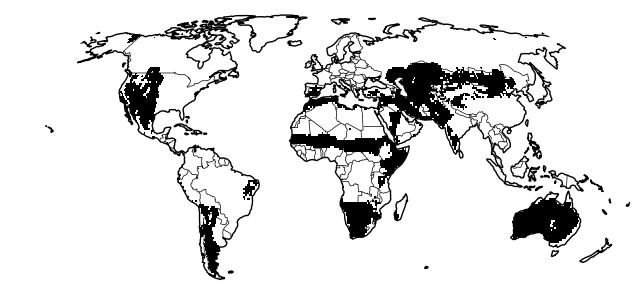

In [27]:
nrows = 1
ncols = 1
proj = ccrs.Robinson(central_longitude=0)

fig, axes = plt.subplots(
    nrows=nrows,
    ncols=ncols,
    figsize=(8 * ncols, 4 * nrows),
    subplot_kw={'projection': proj}
)

for ct, ax in enumerate(np.atleast_1d(axes).flatten()):

    if ct == 0:
        to_plot = is_arid_semi
        cmap = plt.cm.Grays
        label = r'Is arid/semiarid'
        levels = np.arange(0, 1.1, 0.1)

    norm = BoundaryNorm(levels, ncolors=256)
    to_plot = to_plot.sel(lat=slice(-60, 80))
    # pcolormesh expects arrays; add cyclic point to avoid a seam at 180°
    lon = to_plot['lon'].values
    lat = to_plot['lat'].values
    dat = to_plot.values
    dat_cyc, lon_cyc = add_cyclic_point(dat, coord=lon)

    im = ax.pcolormesh(
        lon_cyc,
        lat,
        dat_cyc,
        cmap=cmap,
        norm=norm,
        transform=ccrs.PlateCarree(),
        shading='auto'
    )

    ax.set_aspect('equal')
    ax.add_feature(cfeature.COASTLINE, zorder=100.)
    ax.set_global()
    ax.axis('off')
    ax.set_extent([-180, 180, -57, 90], crs=ccrs.PlateCarree())
    ax.set_title('')
    ax.add_feature(cfeature.BORDERS, linewidth=0.5)
    ax.add_feature(cfeature.OCEAN, facecolor='white', zorder=1)


plt.savefig('%s/figS04.png' % figdir, dpi=200, bbox_inches='tight')

# S5: residuals with 20CR

In [28]:
# Load ERA5
da_target = xr.open_dataarray('%s/ERA5_q_1x1.nc' % procdir).load()

# Load 20CR
da_reference = xr.open_dataarray('/home/data/20CR/monthly/shum/shum.2m.mon.mean_ERA5grid1x1.nc')

da_delta = (da_target - da_reference).load()

# Remove differences in mean seasonal cycle
da_delta = da_delta.groupby('time.month') - da_delta.groupby('time.month').mean()

# For each gridbox, calculate trend, variance, AR(1)
trend, _ = xutils.xr_linregress_pval(da_delta, time_dim='time')

# remove trend to get variance
da_detrended = xutils.detrend_xarray(da_delta, dim='time')

std_by_month = da_detrended.groupby('time.month').std()

# get autocorrelation -- shift by 1
ar1 = xr.corr(da_detrended.shift(time=1), da_detrended, dim='time')

# Save these metrics
ds_metrics = xr.merge((trend.rename('trend per year'),
                       std_by_month.rename('sigma'),
                       ar1.rename('AR1 coeff')))


converting time[ns] to year


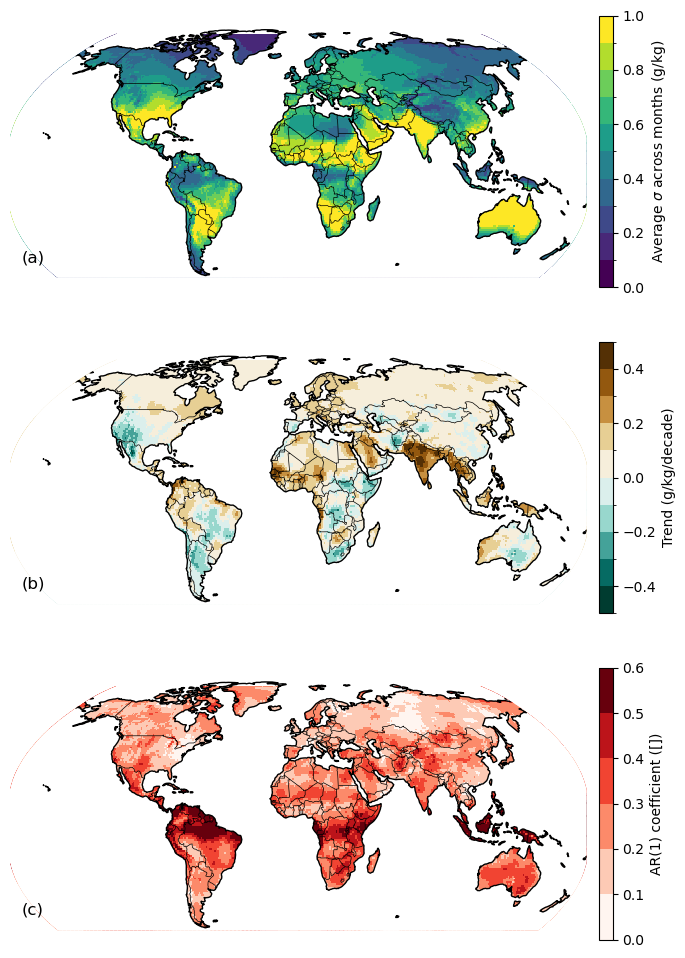

In [29]:
nrows = 3
ncols = 1
proj = ccrs.Robinson(central_longitude=0)

fig, axes = plt.subplots(
    nrows=nrows,
    ncols=ncols,
    figsize=(8 * ncols, 4 * nrows),
    subplot_kw={'projection': proj}
)

for ct, ax in enumerate(np.atleast_1d(axes).flatten()):

    if ct == 0:
        to_plot = std_by_month.mean('month')
        cmap = plt.cm.viridis
        label = r'Average $\sigma$ across months (g/kg)'
        levels = np.arange(0, 1.1, 0.1)

    elif ct == 1:
        to_plot = 10 * trend
        cmap = plt.cm.BrBG_r
        label = 'Trend (g/kg/decade)'
        levels = np.arange(-0.5, 0.6, 0.1)

    else:
        to_plot = ar1
        cmap = plt.cm.Reds
        label = 'AR(1) coefficient ([])'
        levels = np.arange(0, 0.7, 0.1)

    norm = BoundaryNorm(levels, ncolors=256)
    to_plot = to_plot.sel(lat=slice(-60, 80))
    # pcolormesh expects arrays; add cyclic point to avoid a seam at 180°
    lon = to_plot['lon'].values
    lat = to_plot['lat'].values
    dat = to_plot.values
    dat_cyc, lon_cyc = add_cyclic_point(dat, coord=lon)

    im = ax.pcolormesh(
        lon_cyc,
        lat,
        dat_cyc,
        cmap=cmap,
        norm=norm,
        transform=ccrs.PlateCarree(),
        shading='auto'
    )

    ax.set_aspect('equal')
    ax.add_feature(cfeature.COASTLINE, zorder=100.)
    ax.set_global()
    ax.axis('off')
    ax.set_extent([-180, 180, -57, 90], crs=ccrs.PlateCarree())
    ax.set_title('')
    ax.add_feature(cfeature.BORDERS, linewidth=0.5)
    ax.add_feature(cfeature.OCEAN, facecolor='white', zorder=1)

    ax.text(0.02, 0.06, '(%s)' % letters[ct], fontsize=fontsize, transform=ax.transAxes)

    # Colorbar per panel (manual, like your other figure)
    cbar = fig.colorbar(im, ax=ax, orientation='vertical', pad=0.02, fraction=0.05)
    cbar.set_label(label)

plt.savefig('%s/figS05.png' % figdir, dpi=200, bbox_inches='tight')